In [ ]:
#@title Convert XML file to CSV file (SKIP THIS CELL) (ONLY EXECUTE IF YOU HAVE THE XML FILE FROM SUMO (OpenStreetMap Trace for a Sparse Traffic.xml))

import xml.etree.ElementTree as ET
import csv

tree = ET.parse('Data/OpenStreetMap Trace for a Sparse Traffic.xml')  # replace with your file path
root = tree.getroot()

# open a file for writing
with open('Data/sparse.csv', 'w', newline='') as out_csv:
    writer = csv.writer(out_csv)
    writer.writerow(["time", "id", "x", "y", "angle", "type", "speed", "pos", "lane", "slope"])

    for timestep in root.findall('timestep'):
        time = timestep.get('time')
        for vehicle in timestep.findall('vehicle'):
            id = vehicle.get('id')
            x = vehicle.get('x')
            y = vehicle.get('y')
            angle = vehicle.get('angle')
            type = vehicle.get('type')
            speed = vehicle.get('speed')
            pos = vehicle.get('pos')
            lane = vehicle.get('lane')
            slope = vehicle.get('slope')
            writer.writerow([time, id, x, y, angle, type, speed, pos, lane, slope])

In [ ]:
#@title Read the input data (Decompress sparse.zip if you haven't already) - (SKIP THIS CELL IF YOU ARE WORKING WITH preprocessed_sparse.csv)

import pandas as pd

# from google.colab import drive
# drive.mount('/content/drive')

# Load data
data = pd.read_csv('Data/sparse.csv')
# data = pd.read_csv('/content/drive/MyDrive/2024-05- 7088CEM (ANN Module)/Assignments/handover_prediction/Data/sparse.csv')
data.head()
data.info()
data.describe()

In [ ]:
#@title Preprocess data (getting rid of unnecessary columns) (SKIP THIS CELL IF YOU ARE WORKING WITH preprocessed_sparse.csv (You can decompress the zip file with the same name))
# Convert the 'time' column to float and then to integer
data['time'] = data['time'].astype(float).astype(int)

# Remove 'veh' from 'id' column and convert to integer
data['id'] = data['id'].str.replace('veh', '').astype(int)

# Remove specified columns
columns_to_remove = ['type', 'lane', 'slope', 'pos']
data = data.drop(columns=columns_to_remove)

# Display the first few rows of the processed data
data.head(20)
data.info()
data.describe()

# Save the preprocessed DataFrame to a CSV file for future use
# output_path = '/content/drive/MyDrive/2024-05-7088CEM (ANN Module)/Assignments/handover_prediction/Data/preprocessed_sparse.csv'
output_path = 'Data/preprocessed_sparse.csv'
data.to_csv(output_path, index=False)

print(f"Preprocessed data saved to {output_path}")

In [7]:
#@title Preprocesing: Preparing train and test datasets (Save sequenced data) (YOU CAN SKIP THIS BY DECOMPRESSING sequences_vehicle_ids.zip)
import pickle
import pandas as pd

save_path = f'Data/preprocessed_sparse.csv'
data = pd.read_csv(save_path)

sequence_length = 5

def create_sequences(data, sequence_length):
    sequences = [] # each seqence has the properties of one vehicle in different time steps (sequential)
    vehicle_ids = []
    for veh_id, group in data.groupby('id'):
        group = group.sort_values(by='time')
        for i in range(len(group) - sequence_length):
            seq = group.iloc[i:i+sequence_length]
            target = group.iloc[i+sequence_length][['x', 'y']].values  # Use the next row's coordinates as target
            sequences.append((seq[['x', 'y', 'speed', 'angle']].values, target))
            vehicle_ids.append(veh_id)
    return sequences, vehicle_ids

sequences, vehicle_ids = create_sequences(data, sequence_length)
# Save sequences and vehicle IDs to a file

# Print three example sequences and their targets
for i in range(3):
    print(f"\n---\nSequence {i+1}:")
    print("Features (x, y, speed, angle):")
    print(sequences[i][0])
    print("Target (next x, y):")
    print(sequences[i][1])

# with open('/content/drive/MyDrive/2024-05- 7088CEM (ANN Module)/Assignments/handover_prediction/Data/sequences_vehicle_ids.pkl', 'wb') as f:
with open('Data/sequences_vehicle_ids.pkl', 'wb') as f:
    pickle.dump((sequences, vehicle_ids), f)

# how to load it later?
# with open('Data/sequences_vehicle_ids.pkl', 'rb') as f:
#     sequences, vehicle_ids = pickle.load(f)


---
Sequence 1:
Features (x, y, speed, angle):
[[5.01420e+02 1.47312e+03 0.00000e+00 2.90000e-01]
 [5.01430e+02 1.47508e+03 1.96000e+00 2.90000e-01]
 [5.01370e+02 1.47955e+03 4.44000e+00 3.59340e+02]
 [5.01110e+02 1.48568e+03 6.02000e+00 3.57640e+02]
 [5.00760e+02 1.49423e+03 8.40000e+00 3.57640e+02]]
Target (next x, y):
[ 500.34 1504.42]

---
Sequence 2:
Features (x, y, speed, angle):
[[5.01430e+02 1.47508e+03 1.96000e+00 2.90000e-01]
 [5.01370e+02 1.47955e+03 4.44000e+00 3.59340e+02]
 [5.01110e+02 1.48568e+03 6.02000e+00 3.57640e+02]
 [5.00760e+02 1.49423e+03 8.40000e+00 3.57640e+02]
 [5.00340e+02 1.50442e+03 1.00100e+01 3.57640e+02]]
Target (next x, y):
[ 499.83 1516.71]

---
Sequence 3:
Features (x, y, speed, angle):
[[ 501.37 1479.55    4.44  359.34]
 [ 501.11 1485.68    6.02  357.64]
 [ 500.76 1494.23    8.4   357.64]
 [ 500.34 1504.42   10.01  357.64]
 [ 499.83 1516.71   12.26  357.61]]
Target (next x, y):
[ 499.24 1530.83]


In [2]:
#@title (OPTIONAL) Load the preprocessed data (Start from here if you have the sequences_vehicle_ids.pkl file)

import pickle
import pandas as pd

with open('Data/sequences_vehicle_ids.pkl', 'rb') as f:
    sequences, vehicle_ids = pickle.load(f)

print(len(sequences))

for i in range(1465425):
  if i > 1465222:
    print(sequences[i])

1465425
(array([[ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56]]), array([ 938.09, 1295.14]))
(array([[ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56]]), array([ 938.09, 1295.14]))
(array([[ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56]]), array([ 938.09, 1295.14]))
(array([[ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56],
       [ 938.09, 1295.14,    0.  ,  273.56]]),

In [3]:
#@title (OPTIONAL) checking the number of unique vehicle ids
# Convert the data into a DataFrame
import pandas as pd
import numpy as np

file_path = 'Data/preprocessed_sparse.csv'  # Update this path if necessary
df = pd.read_csv(file_path)



# Get unique IDs and sort them
unique_ids = sorted(df['id'].unique())


# Check for gaps in the IDs
id_gaps = []
total_missing_ids = 0

for i in range(1, len(unique_ids)):
    if unique_ids[i] != unique_ids[i-1] + 1:
        gap_start = unique_ids[i-1]
        gap_end = unique_ids[i]
        gap_size = gap_end - gap_start - 1
        id_gaps.append((gap_start, gap_end, gap_size))
        total_missing_ids += gap_size

# Display results
print(f"Total unique IDs: {len(unique_ids)}")
print(f"Unique IDs: {unique_ids}")

if id_gaps:
    print("\nGaps found between the following IDs:")
    for gap in id_gaps:
        print(f"{gap[0]} -> \033[91m*\033[0m -> {gap[1]} (Missing {gap[2]} IDs)")
    print(f"\nTotal number of gaps: {len(id_gaps)}")
    print(f"Total number of missing IDs in gaps: {total_missing_ids}")
else:
    print("\nNo gaps found between the IDs.")

Total unique IDs: 3592
Unique IDs: [0, 1, 2, 3, 4, 5, 7, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 25, 26, 27, 28, 29, 30, 32, 33, 34, 36, 37, 38, 42, 43, 45, 46, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 142, 143, 144, 145, 146, 149, 150, 151, 152, 153, 154, 155, 156, 160, 162, 163, 164, 165, 166, 167, 168, 170, 171, 173, 174, 175, 176, 178, 179, 180, 182, 183, 184, 186, 188, 190, 192, 193, 194, 195, 197, 199, 200, 201, 202, 203, 204, 205, 206, 207, 210, 211, 212, 213, 214, 215, 216, 217, 221, 222, 223, 224, 225, 226, 227, 228, 230, 231, 232, 233, 234, 237, 238, 239, 240, 241, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 257, 258,

------------------------------------
Max x: 1420.58
Row for max x:
time     2198.00
id       2549.00
x        1420.58
y        1661.63
angle      90.54
speed      17.04
Name: 428232, dtype: float64

------------------------------------
Min x: 2.14
Row for min x:
time      117.00
id        141.00
x           2.14
y        1666.14
angle      60.79
speed      17.85
Name: 5684, dtype: float64

Max y: 2212.71
Row for max y:
time      384.00
id        389.00
x         509.39
y        2212.71
angle       0.17
speed      30.96
Name: 29667, dtype: float64

------------------------------------
Min y: 820.68
Row for min y:
time     2628.00
id       3051.00
x         859.29
y         820.68
angle     206.09
speed      15.88
Name: 563510, dtype: float64

Max speed: 37.38
Row for max speed:
time     3880.00
id       3486.00
x         515.67
y        2173.05
angle       0.17
speed      37.38
Name: 1074600, dtype: float64

------------------------------------
Min speed: 0.0
Row for min speed:
time    

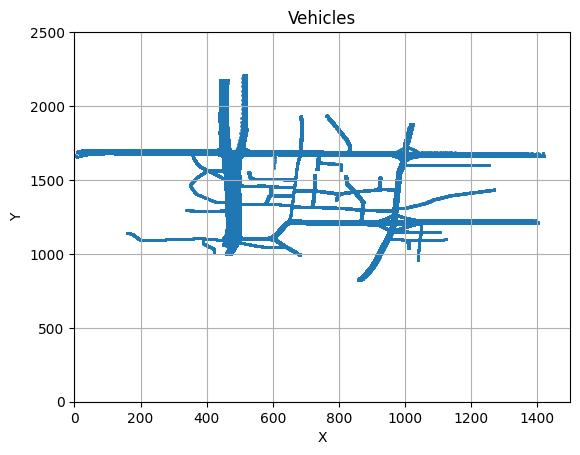

In [6]:
#@title (OPTIONAL) Some statistical analysis on the data
import matplotlib.pyplot as plt

# Find the max and min of 'x'
max_x = df['x'].max()
min_x = df['x'].min()

# Find the row for max and min 'x'
row_max_x = df.loc[df['x'].idxmax()]
row_min_x = df.loc[df['x'].idxmin()]

# Find the max and min of 'y'
max_y = df['y'].max()
min_y = df['y'].min()

# Find the row for max and min 'y'
row_max_y = df.loc[df['y'].idxmax()]
row_min_y = df.loc[df['y'].idxmin()]

# Find the max and min of 'speed'
max_speed = df['speed'].max()
min_speed = df['speed'].min()

# Find the row for max and min 'speed'
row_max_speed = df.loc[df['speed'].idxmax()]
row_min_speed = df.loc[df['speed'].idxmin()]

# Print the results
print(f"------------------------------------\nMax x: {max_x}\nRow for max x:\n{row_max_x}\n")
print(f"------------------------------------\nMin x: {min_x}\nRow for min x:\n{row_min_x}\n")
print(f"===================\nMax y: {max_y}\nRow for max y:\n{row_max_y}\n")
print(f"------------------------------------\nMin y: {min_y}\nRow for min y:\n{row_min_y}\n")
print(f"===================\nMax speed: {max_speed}\nRow for max speed:\n{row_max_speed}\n")
print(f"------------------------------------\nMin speed: {min_speed}\nRow for min speed:\n{row_min_speed}\n")

# Find the number of distinct vehicles
num_vehicles = df['id'].nunique()

# Print the number of distinct vehicles
print(f"===================\nNumber of distinct vehicles: {num_vehicles}")

# Group by time and count the number of vehicles (rows) for each time step
time_group = df.groupby('time').size()

# Find the maximum number of vehicles in a time step
max_vehicles = time_group.max()
max_vehicles_time_step = time_group.idxmax()

# Calculate the average number of vehicles per time step
average_vehicles_per_time_step = time_group.mean()

# Check for any time steps with no vehicles recorded
total_time_steps = 8219  # You mentioned there are 8219 seconds
all_time_steps = set(range(total_time_steps))
recorded_time_steps = set(time_group.index)

# Find the missing time steps
missing_time_steps = sorted(all_time_steps - recorded_time_steps)

# Display results
print(f"Maximum number of vehicles in any time step: {max_vehicles}")
print(f"Time step with maximum vehicles: {max_vehicles_time_step}")

print(f"Average number of vehicles per time step: {average_vehicles_per_time_step:.2f}")


if missing_time_steps:
    print(f"\nTime steps with no vehicles recorded: {missing_time_steps}")
    print(f"Total number of missing time steps: {len(missing_time_steps)}")
else:
    print("\nAll time steps have at least one vehicle recorded.")

################################################
# Create a scatter plot of the vehicles over all time steps
X_LIM = 1500
Y_LIM = 2500

plt.scatter(df['x'], df['y'], s=1)  # s parameter is used to make the points smaller

plt.xlim(0, X_LIM)
plt.ylim(0, Y_LIM)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vehicles')
plt.grid(True)
plt.savefig(f'Graphs/raw-actual-locations.svg', bbox_inches='tight')
plt.show()